# Preprocessing data

In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import json

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model")

In [3]:
sys.path.append(PROJECT_DIR)

from modules.getting_input_data import get_input_data

input_file_name = "data/input_file.xlsx"
input_data = get_input_data(PROJECT_DIR, input_file_name)

File found at: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/input_file.xlsx
The input data has been imported.


In [4]:
project_name = input_data["project_name"]
zones = json.loads(input_data["zones"])
year = input_data["year"]
scenario =  input_data["scenario"]

INTER_DIR = os.path.join(PROJECT_DIR, input_data["subfolder"])

### Demand Profiles Introduction

In [5]:
# Define the path to the demand profiles file
demand_profiles_path = os.path.join(INTER_DIR,project_name, f"demand_profiles_{scenario}_{year}.csv")

# Load the data and parse datetime in column 0
try:
    demand_profiles = pd.read_csv(demand_profiles_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully loaded demand profiles. Shape: {demand_profiles.shape}")
    display(demand_profiles.head(3))
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(demand_profiles_path)} was not found.\nCheck if it exists in {os.path.dirname(demand_profiles_path)}.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded demand profiles. Shape: (8784, 81)


,AT00_H2_zone_1,AT00_H2_zone_2,AT00_H2_heat,AT00_CH4_heat,AT00_El_market,AT00_El_prosumer,AT00_SNG,AT00_eDiesel,AT00_eKerosine,ITSI_H2_zone_1,...,ITN1_eKerosine,SI00_H2_zone_1,SI00_H2_zone_2,SI00_H2_heat,SI00_CH4_heat,SI00_El_market,SI00_El_prosumer,SI00_SNG,SI00_eDiesel,SI00_eKerosine
2040-01-01 00:00:00,1238.505084,4701.660764,2612.082863,0.0,2009.0000,2009.0000,13.584475,17.922374,15.152332,0.0,...,15.152332,115.479496,423.066858,297.661153,390.261496,2009.0000,2009.0000,13.584475,17.922374,15.152332
2040-01-01 01:00:00,1238.522271,4733.483856,2618.819151,0.0,6408.5376,6349.5306,13.584475,17.922374,15.152332,0.0,...,15.152332,115.486282,425.332321,299.369922,392.498860,657.6318,818.9818,13.584475,17.922374,15.152332
2040-01-01 02:00:00,1238.539457,4839.011940,2856.418998,0.0,6022.8960,6207.1128,13.584475,17.922374,15.152332,0.0,...,15.152332,115.493069,432.803053,327.072571,428.921645,623.2492,795.1398,13.584475,17.922374,15.152332


### Hydrogen Demand
Zone 1 and Zone 2 hydrogen demand



#### H2 demands for zone 1 and zone 2

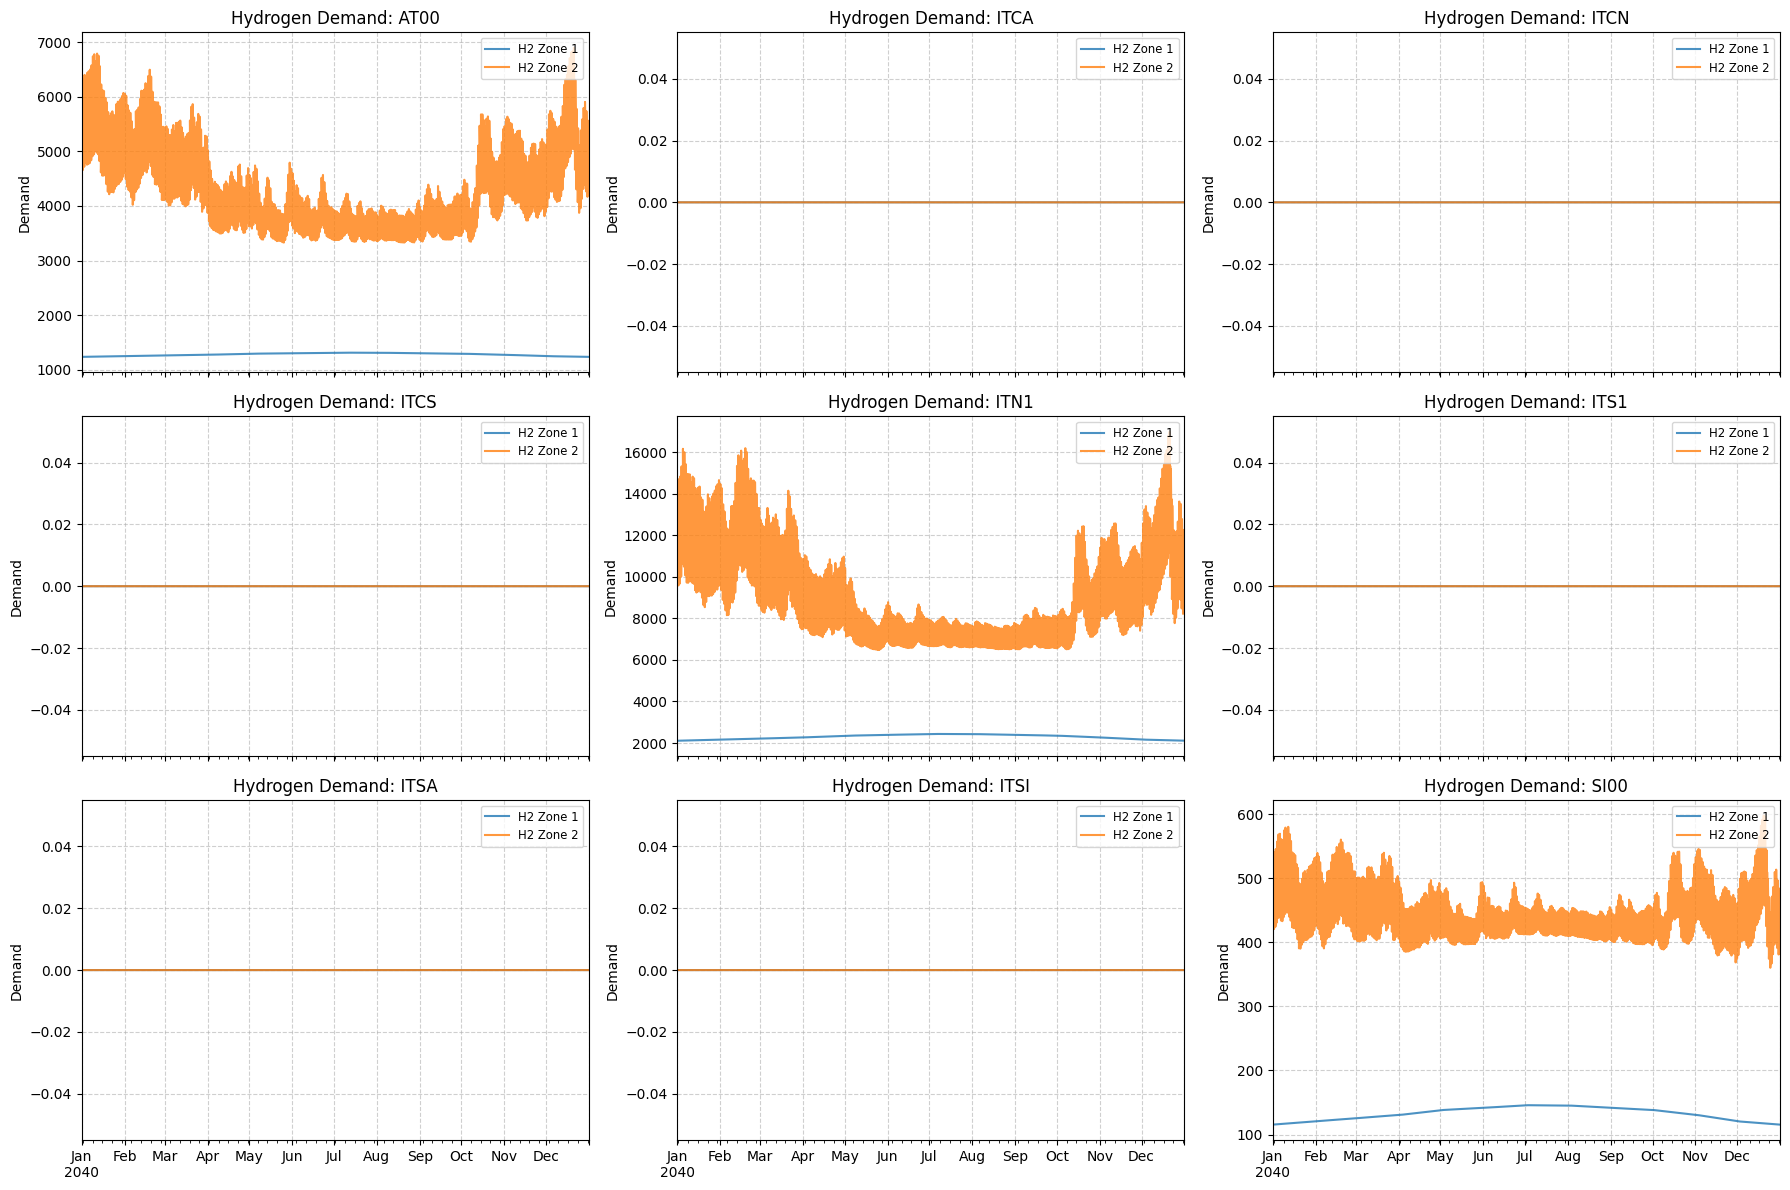

In [6]:
import matplotlib.pyplot as plt
import math

# Identify unique zones from the dataframe columns (e.g., 'AT00' from 'AT00_H2_zone_1')
zones_list = sorted(list(set([col.split('_')[0] for col in demand_profiles.columns if '_H2_zone_' in col])))

n_zones = len(zones_list)
cols = 3
rows = math.ceil(n_zones / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zones_list):
    h2_z1_col = f"{zone}_H2_zone_1"
    h2_z2_col = f"{zone}_H2_zone_2"

    if h2_z1_col in demand_profiles.columns:
        demand_profiles[h2_z1_col].plot(ax=axes[i], label='H2 Zone 1', alpha=0.8)
    if h2_z2_col in demand_profiles.columns:
        demand_profiles[h2_z2_col].plot(ax=axes[i], label='H2 Zone 2', alpha=0.8)

    axes[i].set_title(f'Hydrogen Demand: {zone}')
    axes[i].set_ylabel('Demand')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### H2 Zone 1

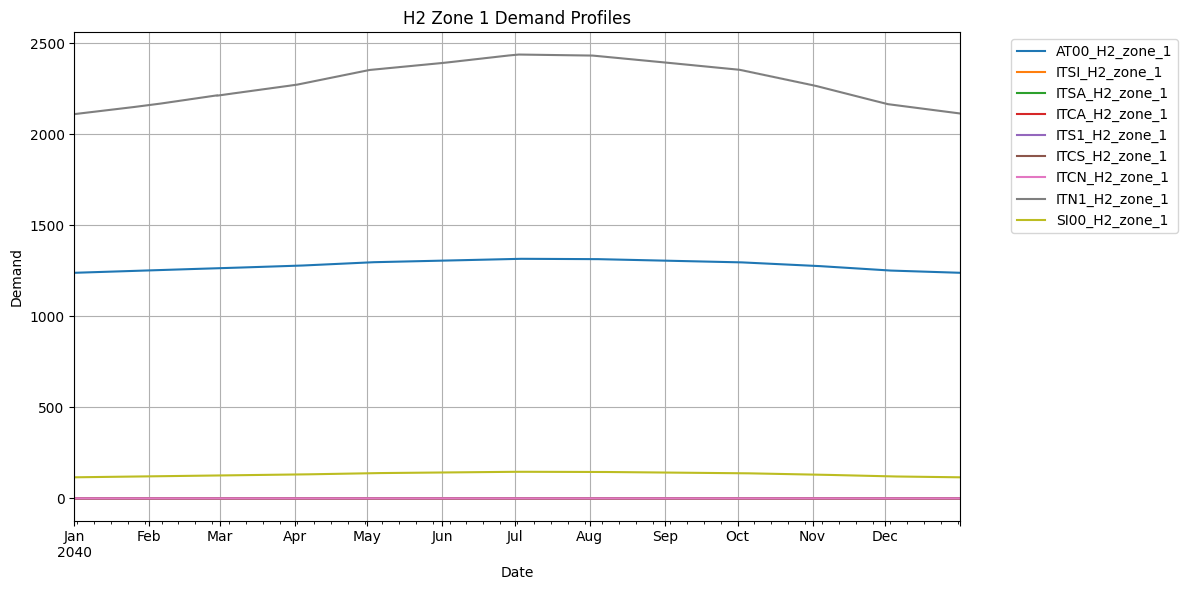

In [7]:
import matplotlib.pyplot as plt

# Filter columns that contain 'H2_zone_1'
h2_zone1_cols = [col for col in demand_profiles.columns if 'H2_zone_1' in col]

# Plot the profiles
if h2_zone1_cols:
    plt.figure(figsize=(12, 6))
    demand_profiles[h2_zone1_cols].plot(ax=plt.gca())
    plt.title('H2 Zone 1 Demand Profiles')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No columns matching 'H2_zone_1' were found.")

In [8]:
demand_profiles['AT00_H2_zone_1'].describe()

,AT00_H2_zone_1
count,8784.000000
mean,1282.723116
std,24.766049
min,1238.505084
25%,1260.205114
50%,1286.727797
75%,1305.236188
max,1315.426372


#### H2 Zone 2

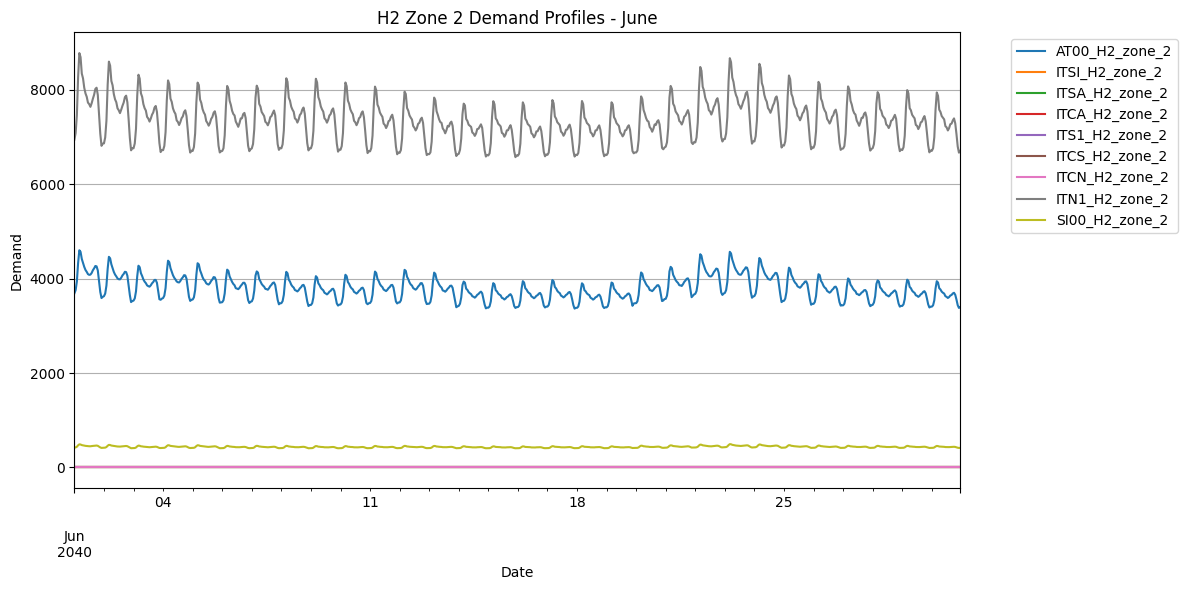

In [9]:
import matplotlib.pyplot as plt

# Filter columns for H2_zone_2 and select June data
h2_zone2_cols = [col for col in demand_profiles.columns if 'H2_zone_2' in col]
june_data = demand_profiles[demand_profiles.index.month == 6]

if h2_zone2_cols:
    plt.figure(figsize=(12, 6))
    june_data[h2_zone2_cols].plot(ax=plt.gca())
    plt.title('H2 Zone 2 Demand Profiles - June')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No columns matching 'H2_zone_2' were found.")

In [10]:
demand_profiles['ITN1_H2_zone_2'].describe()

,ITN1_H2_zone_2
count,8784.000000
mean,9148.632171
std,2222.253290
min,6484.565577
25%,7282.774345
50%,8465.834512
75%,10747.939538
max,16990.467052


### Heating Demand
Heating demands are covered by CH4 and H2

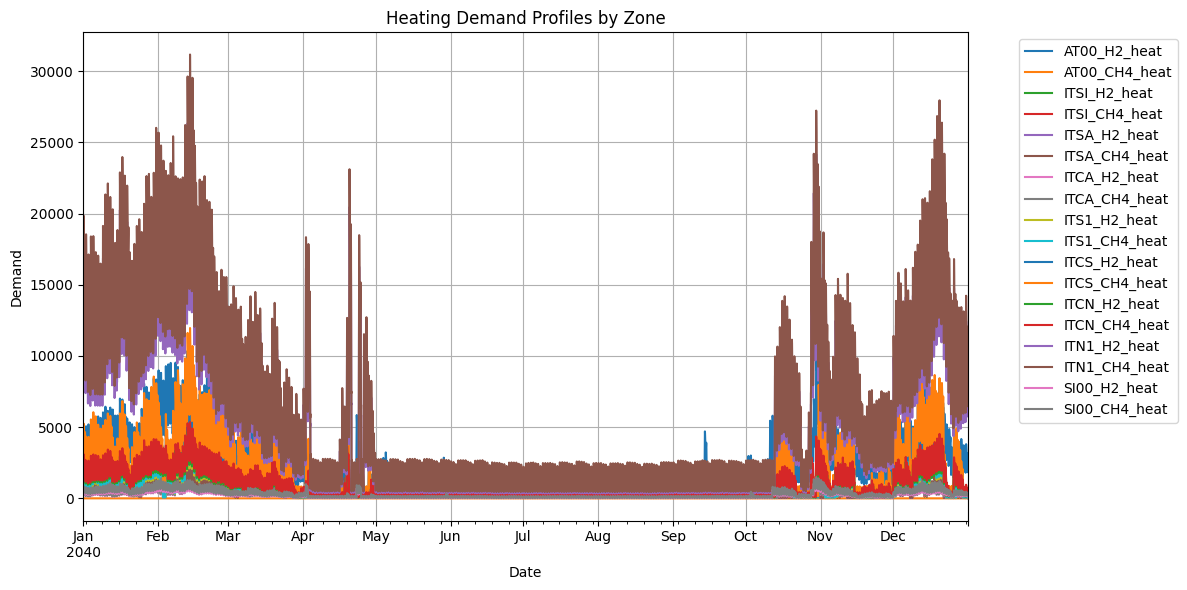

In [11]:
import matplotlib.pyplot as plt

# Filter columns that contain '_heat' for the selected zones
heat_cols = [col for col in demand_profiles.columns if '_heat' in col]

if heat_cols:
    plt.figure(figsize=(12, 6))
    demand_profiles[heat_cols].plot(ax=plt.gca())
    plt.title('Heating Demand Profiles by Zone')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No heating demand columns found in the dataset.")

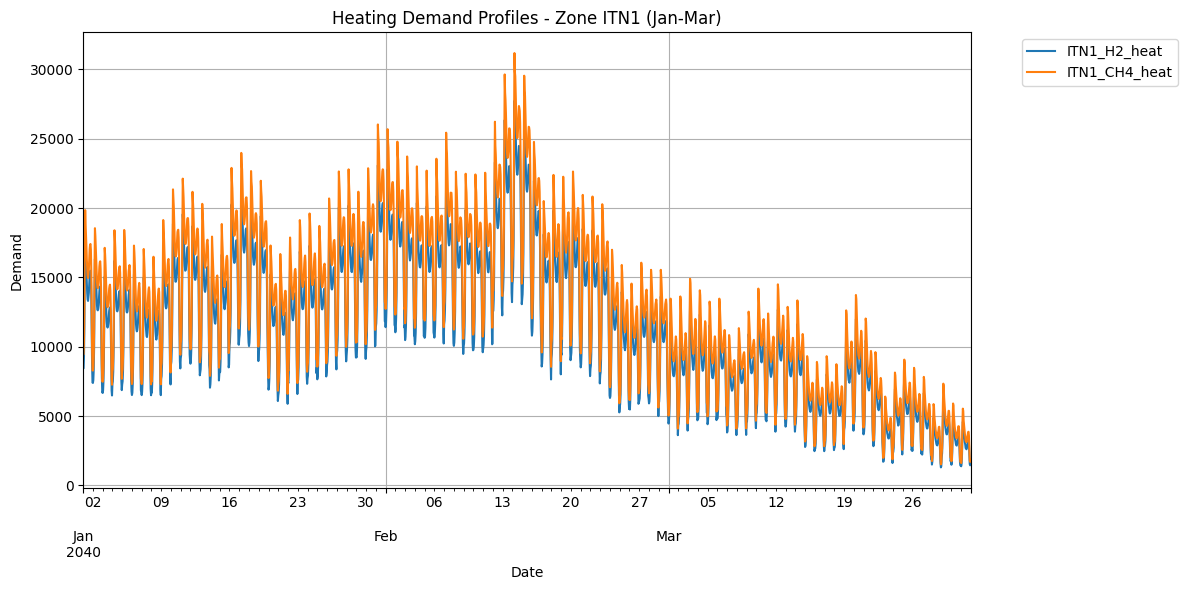

In [12]:
# Filter for ITN1 heating demand columns
itn1_heat_cols = [col for col in heat_cols if 'ITN1' in col]

# Filter data for January to March
jan_to_march_data = demand_profiles[demand_profiles.index.month.isin([1, 2, 3])]

if itn1_heat_cols:
    plt.figure(figsize=(12, 6))
    jan_to_march_data[itn1_heat_cols].plot(ax=plt.gca())
    plt.title('Heating Demand Profiles - Zone ITN1 (Jan-Mar)')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No heating demand columns found for zone ITN1.")

### Electricity Profiles
Electricity demand and prosumer

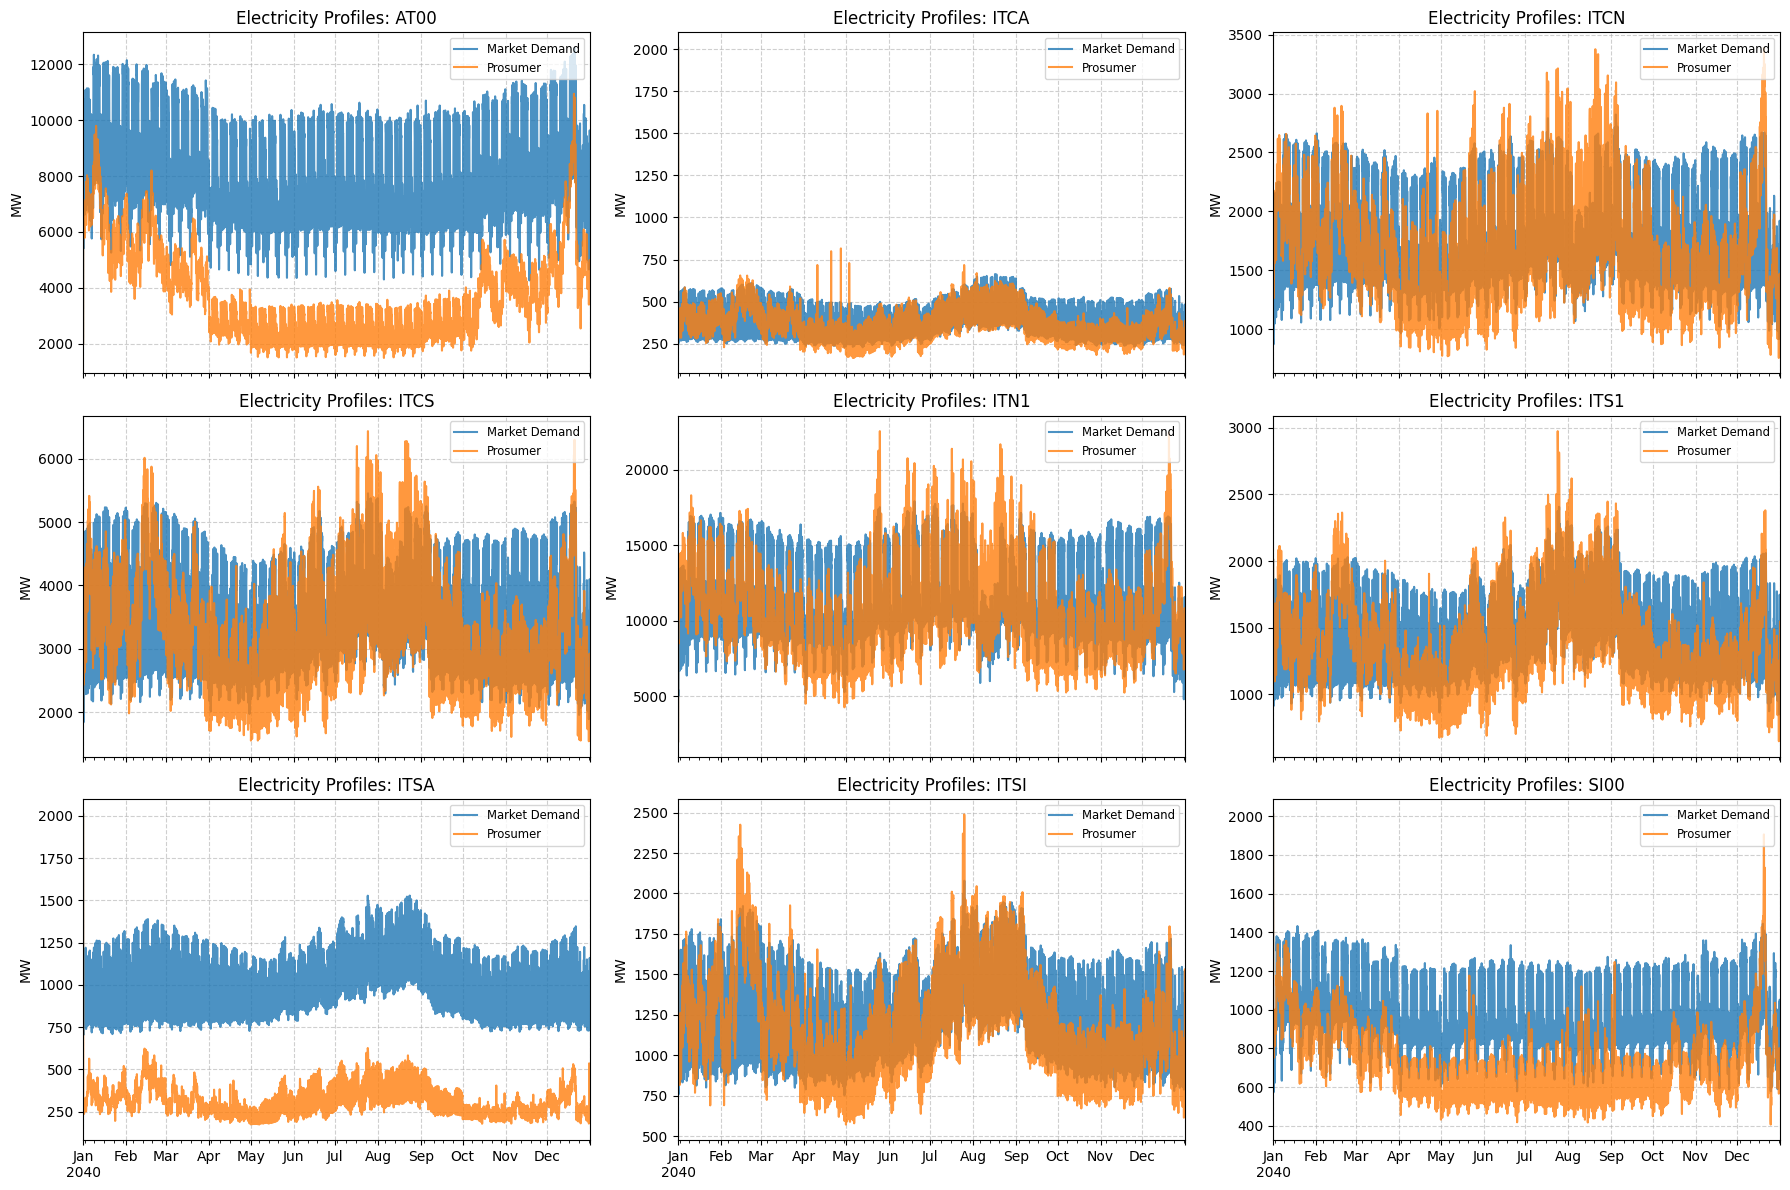

In [13]:
import matplotlib.pyplot as plt
import math

# Identify zones from the dataframe columns (e.g., 'AT00' from 'AT00_El_market')
zones = sorted(list(set([col.split('_')[0] for col in demand_profiles.columns if '_El_' in col])))

n_zones = len(zones)
cols = 3
rows = math.ceil(n_zones / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zones):
    market_col = f"{zone}_El_market"
    prosumer_col = f"{zone}_El_prosumer"

    if market_col in demand_profiles.columns:
        demand_profiles[market_col].plot(ax=axes[i], label='Market Demand', alpha=0.8)
    if prosumer_col in demand_profiles.columns:
        demand_profiles[prosumer_col].plot(ax=axes[i], label='Prosumer', alpha=0.8)

    axes[i].set_title(f'Electricity Profiles: {zone}')
    axes[i].set_ylabel('MW')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Synthetic Fuels

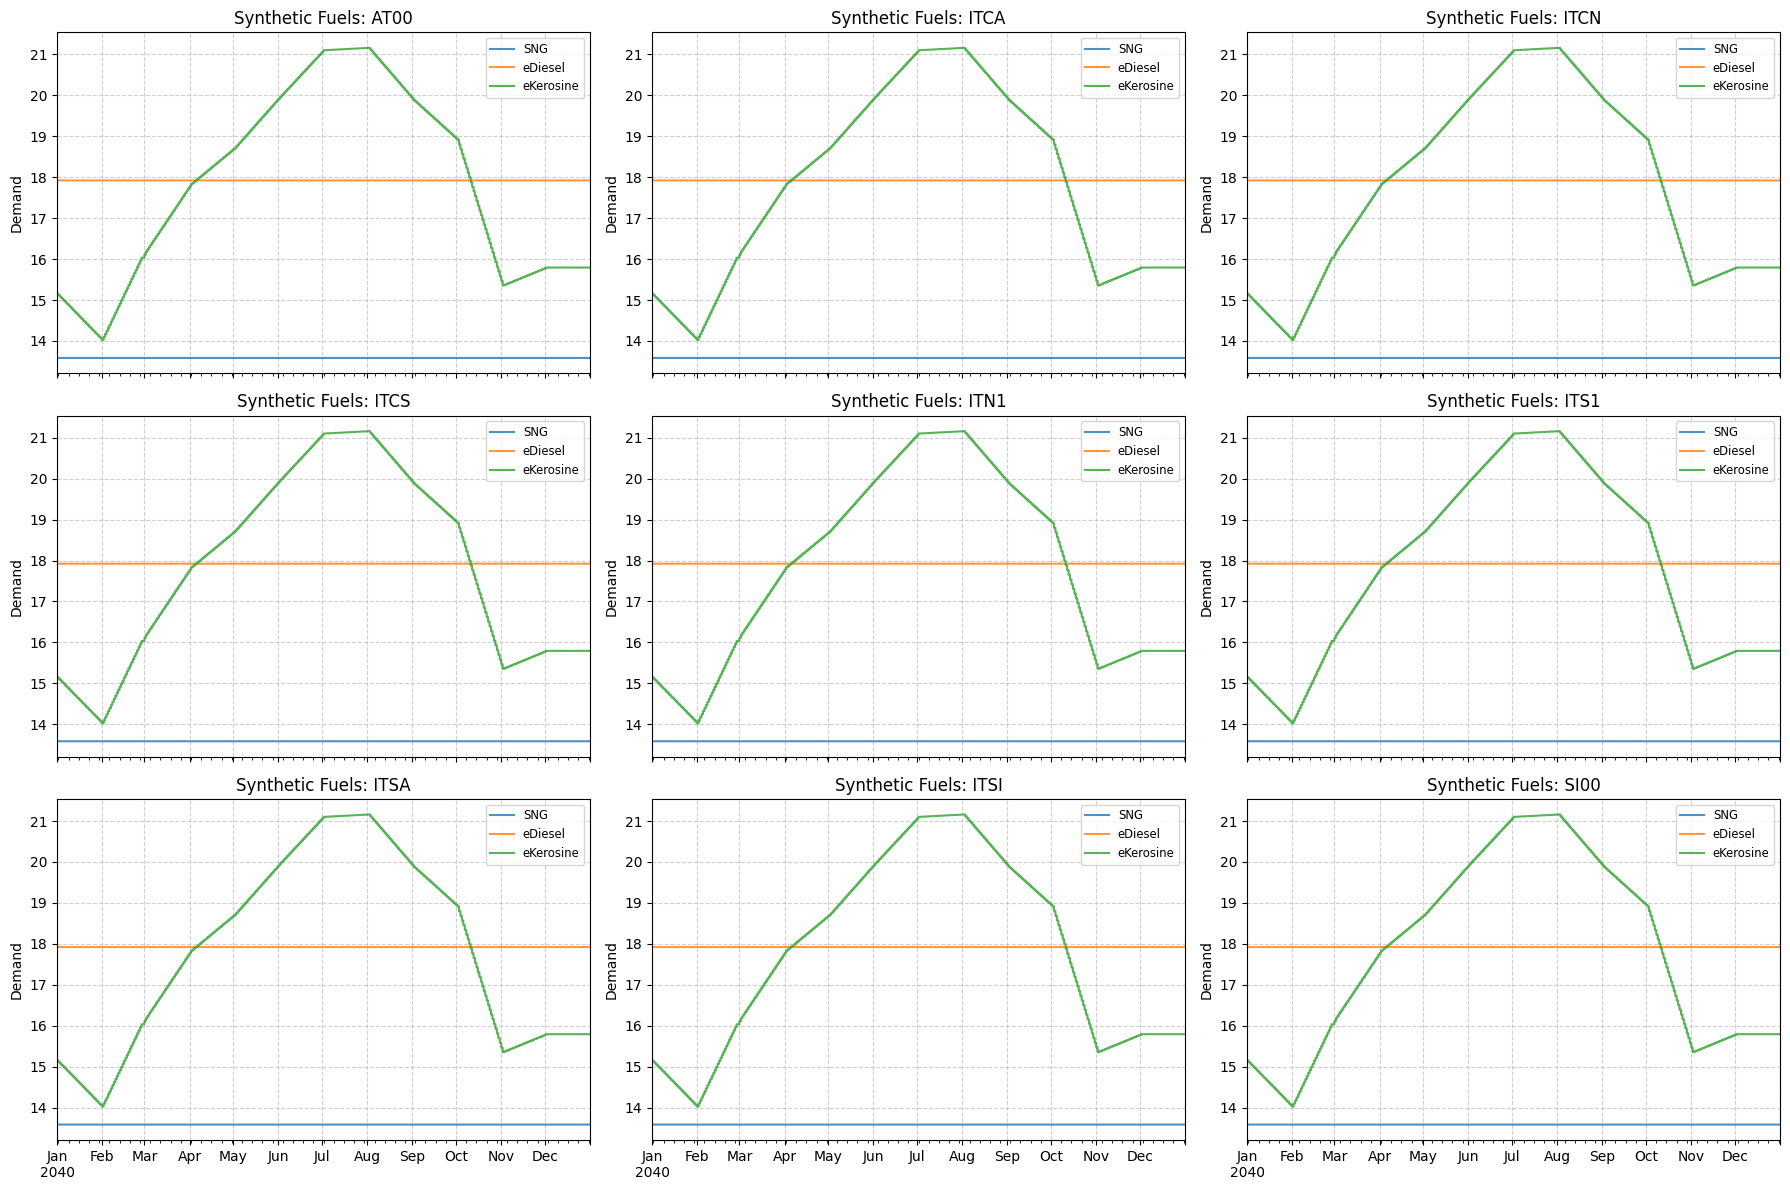

In [14]:
import matplotlib.pyplot as plt
import math

# Identify zones from the columns that contain synthetic fuel keys
syn_fuel_keys = ['_SNG', '_eDiesel', '_eKerosine']
zones = sorted(list(set([col.split('_')[0] for col in demand_profiles.columns if any(key in col for key in syn_fuel_keys)])))

n_zones = len(zones)
cols = 3
rows = math.ceil(n_zones / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zones):
    sng_col = f"{zone}_SNG"
    diesel_col = f"{zone}_eDiesel"
    kerosine_col = f"{zone}_eKerosine"

    if sng_col in demand_profiles.columns:
        demand_profiles[sng_col].plot(ax=axes[i], label='SNG', alpha=0.8)
    if diesel_col in demand_profiles.columns:
        demand_profiles[diesel_col].plot(ax=axes[i], label='eDiesel', alpha=0.8)
    if kerosine_col in demand_profiles.columns:
        demand_profiles[kerosine_col].plot(ax=axes[i], label='eKerosine', alpha=0.8)

    axes[i].set_title(f'Synthetic Fuels: {zone}')
    axes[i].set_ylabel('Demand')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

demand_summary = []
for z in zones:
    # Correctly identify the column name in demand_profiles
    column_name = f"{z}_El_market"
    if column_name in demand_profiles.columns:
        series = demand_profiles[column_name]
        avg_mw = series.mean()
        total_twh = series.sum() / 1e6 # MW * h / 1,000,000 = TWh
        demand_summary.append({
            'Zone': z,
            'Avg Hourly Demand (MW)': avg_mw,
            'Annual Demand (TWh)': total_twh
        })

df_demand = pd.DataFrame(demand_summary).set_index('Zone')
print(f"Electricity Demand Summary ({scenario} {year}):")
display(df_demand.round(2))

Electricity Demand Summary (GA 2040):


,Avg Hourly Demand (MW),Annual Demand (TWh)
Zone,,
AT00,8341.82,73.27
ITCA,397.57,3.49
ITCN,1847.16,16.23
ITCS,3643.60,32.01
ITN1,11750.88,103.22
ITS1,1512.68,13.29
ITSA,1044.04,9.17
ITSI,1286.61,11.30
SI00,995.66,8.75


### Demand Profiles

In [16]:
# List all columns in the demand_profiles DataFrame
print(demand_profiles.columns.tolist())

['AT00_H2_zone_1', 'AT00_H2_zone_2', 'AT00_H2_heat', 'AT00_CH4_heat', 'AT00_El_market', 'AT00_El_prosumer', 'AT00_SNG', 'AT00_eDiesel', 'AT00_eKerosine', 'ITSI_H2_zone_1', 'ITSI_H2_zone_2', 'ITSI_H2_heat', 'ITSI_CH4_heat', 'ITSI_El_market', 'ITSI_El_prosumer', 'ITSI_SNG', 'ITSI_eDiesel', 'ITSI_eKerosine', 'ITSA_H2_zone_1', 'ITSA_H2_zone_2', 'ITSA_H2_heat', 'ITSA_CH4_heat', 'ITSA_El_market', 'ITSA_El_prosumer', 'ITSA_SNG', 'ITSA_eDiesel', 'ITSA_eKerosine', 'ITCA_H2_zone_1', 'ITCA_H2_zone_2', 'ITCA_H2_heat', 'ITCA_CH4_heat', 'ITCA_El_market', 'ITCA_El_prosumer', 'ITCA_SNG', 'ITCA_eDiesel', 'ITCA_eKerosine', 'ITS1_H2_zone_1', 'ITS1_H2_zone_2', 'ITS1_H2_heat', 'ITS1_CH4_heat', 'ITS1_El_market', 'ITS1_El_prosumer', 'ITS1_SNG', 'ITS1_eDiesel', 'ITS1_eKerosine', 'ITCS_H2_zone_1', 'ITCS_H2_zone_2', 'ITCS_H2_heat', 'ITCS_CH4_heat', 'ITCS_El_market', 'ITCS_El_prosumer', 'ITCS_SNG', 'ITCS_eDiesel', 'ITCS_eKerosine', 'ITCN_H2_zone_1', 'ITCN_H2_zone_2', 'ITCN_H2_heat', 'ITCN_CH4_heat', 'ITCN_El_mar

### NTC Hydrogen

In [17]:
import pandas as pd
import os

# Path to the specific hydrogen line data file
h2_line_path = os.path.join(PROJECT_DIR, "data", "Line data", "ReferenceGrid_Hydrogen.xlsx")

try:
    # Read the specific sheet '2030'
    ntc_h2_raw_df = pd.read_excel(h2_line_path, sheet_name='2030')
    print(f"✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: {ntc_h2_raw_df.columns.tolist()}")

    # Display the first few rows to verify structure
    display(ntc_h2_raw_df.head())

except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(h2_line_path)} was not found in {os.path.dirname(h2_line_data_path)}.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: ['Border', 'Summary Direction 1', 'Summary Direction 2']


,Border,Summary Direction 1,Summary Direction 2
0,AT-DE,6.25,6.25
1,AT-IBIT,5.25,7.00
2,AT-SI,0.00,0.00
3,AT-SK,6.00,6.00
4,BE-DE,3.79,3.79


In [18]:
NTC_h2_prepared = []

# Mapping for hydrogen-specific naming conventions
h2_zone_map = {
    'AT': 'AT00',
    'SI': 'SI00',
    'IBIT': 'ITN1'
}

try:
    for _, row in ntc_h2_raw_df.iterrows():
        border = str(row['Border'])
        if '-' in border:
            parts = border.split('-')
            z1_raw, z2_raw = parts[0].strip(), parts[1].strip()
            z1 = h2_zone_map.get(z1_raw, z1_raw)
            z2 = h2_zone_map.get(z2_raw, z2_raw)

            if z1 in zones and z2 in zones:
                cap1 = float(row['Summary Direction 1']) * 1e3
                cap2 = float(row['Summary Direction 2']) * 1e3

                if cap1 > 0 or cap2 > 0:
                    NTC_h2_prepared.append({
                        'zone 1': z1,
                        'zone 2': z2,
                        'capacity_MW': cap1,
                        'capacity_rev_MW': cap2,
                        'efficiency': 0.98
                    })

    NTC_H2_df = pd.DataFrame(NTC_h2_prepared)

    if not NTC_H2_df.empty:
        print(f"✅ Prepared {len(NTC_H2_df)} hydrogen interconnections.")
        display(NTC_H2_df)
    else:
        print("ℹ️ No matching hydrogen connections found for current project zones.")

except Exception as e:
    print(f"❌ Error processing H2 grid data: {e}")

✅ Prepared 1 hydrogen interconnections.


,zone 1,zone 2,capacity_MW,capacity_rev_MW,efficiency
0,AT00,ITN1,5250.0,7000.0,0.98
